# Convolutional Neural Networks

The concept of convolution can be easily extended to images. In this case, the kernels are matrices. For instance, this kernel represents a smoothing filter 

$$
kernel = \begin{bmatrix}
\frac{1}{9}, \frac{1}{9},\frac{1}{9} \\
\frac{1}{9}, \frac{1}{9},\frac{1}{9} \\
\frac{1}{9}, \frac{1}{9},\frac{1}{9} 
\end{bmatrix}
$$

The kernels operate over all the image image

<div style="text-align:center">
<img src="images/Convolution_arithmetic_-_Full_padding_no_strides.gif" alt="plot" width="400" />
</div>

- Blue $\rightarrow$ input Image
- Gray $\rightarrow$ kernel
- Green $\rightarrow$ output Image


2d CNNS are formed by a combination of kernels, followed by an activation function (non-linearity), and sub-sampling. These layers are stacked to form deep networks that process each image. After processing, the network transforms the image into a single vector called feature map, which is then passed to a fully connected layer which performs the final task (e.g classification or regression).

<div style="text-align:center">
<img src="images/2d-convolution.jpg" alt="plot" width="400" />
</div>


In this notebook, we will train a simple 2d CNN to classify images showing distinct poses, including standing, sitting, and laying down. Here are sample images from the dataset

<div style="text-align:center">
<img src="images/classes.png" alt="plot" width="400" />
</div>

The goal is to train a model to differentiate the different types of posture in each image. 

In [37]:
from pathlib import Path
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

PYTORCH_ENABLE_MPS_FALLBACK=1 

Each image has different dimensions. This does not go well with CNN as all the images must be processed together. The first step is to transform all the images so they all have the same size. This can be achieved by cropping larger images and padding smaller images into a fixed size. 

In [38]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

valid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

You can apply multiple transformation to your data, these are called **Augmentations**. Common transformation include rotating the image, flipping horizontally or vertically, blurring the image, changing colors, etc. 

We can, for example, add random flips and rotations to the data, these are common augmentations that help improve model stability. 

These transformations are only applied to the training data, not to the test data. 

In [48]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

valid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

The data for this project is nicely organized into folders, using this structure:

Main train folder:
- data/posture-classification/train
    * data/posture-classification/train/lying
    * data/posture-classification/train/sitting
    * data/posture-classification/train/standing


Main validation folder:
- data/posture-classification/valid
    * data/posture-classification/valid/lying
    * data/posture-classification/valid/sitting
    * data/posture-classification/valid/standing


Using this data structure, is possible to import the data directly into PyTorch 

In [49]:
train_dir= "data/posture-classification/train"
valid_dir= "data/posture-classification/valid"
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
valid_dataset = datasets.ImageFolder(valid_dir, transform=valid_transform)

Now, is possible to create the object that will pass the images to the trainer in batches. 

In [50]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
print("Classes:", class_names)
print("Class to index:", train_dataset.class_to_idx)
print("Number of training images:", len(train_dataset))
print("Number of validation images:", len(valid_dataset))

Classes: ['lying', 'sitting', 'standing']
Class to index: {'lying': 0, 'sitting': 1, 'standing': 2}
Number of training images: 964
Number of validation images: 108


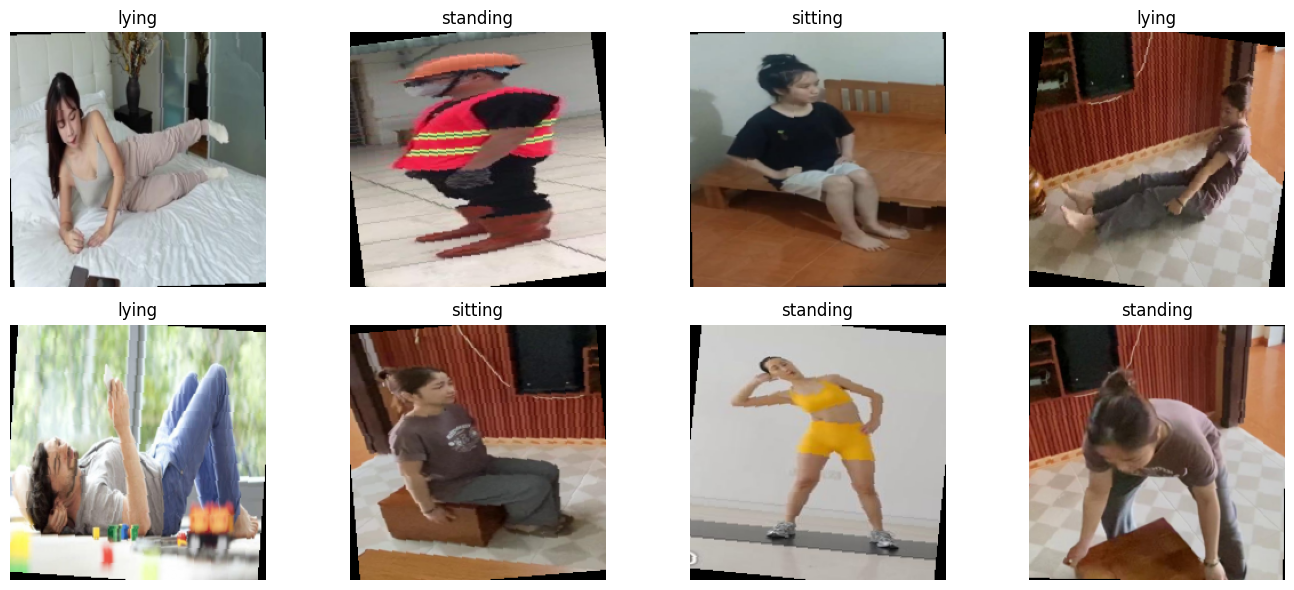

In [51]:
def show_batch(images, labels, class_names, n=8):
    plt.figure(figsize=(14, 6))
    for i in range(min(n, len(images))):
        ax = plt.subplot(2, 4, i + 1)
        img = images[i].permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

#these are the images after the transforms, so they will be resized and normalized
images, labels = next(iter(train_loader))
show_batch(images, labels, class_names)

Lets create a simple model that receives each image and transforms it with kernels and nonlinearities 

In [55]:
class SimplePostureCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

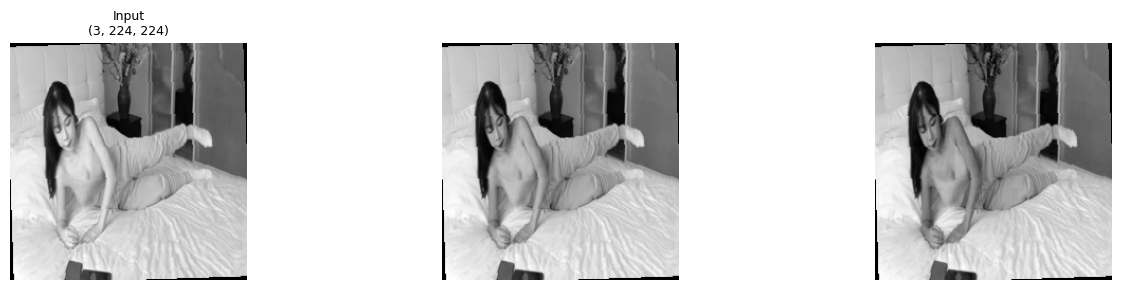

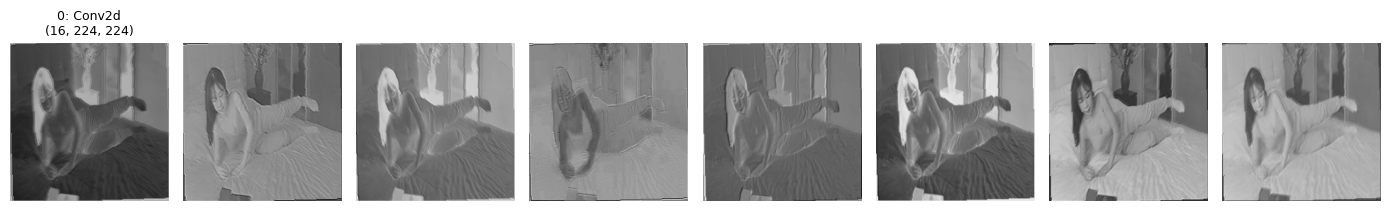

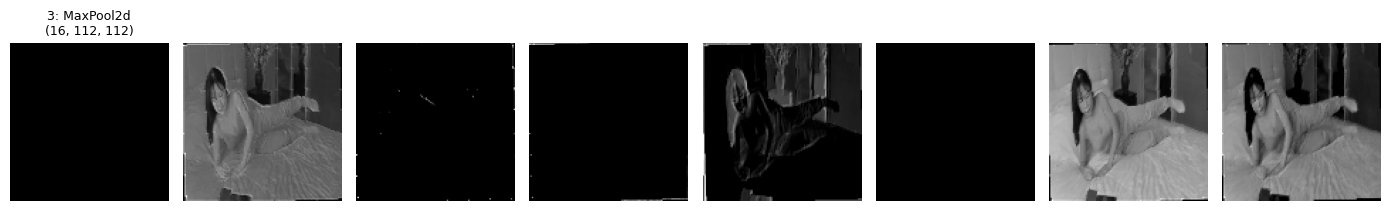

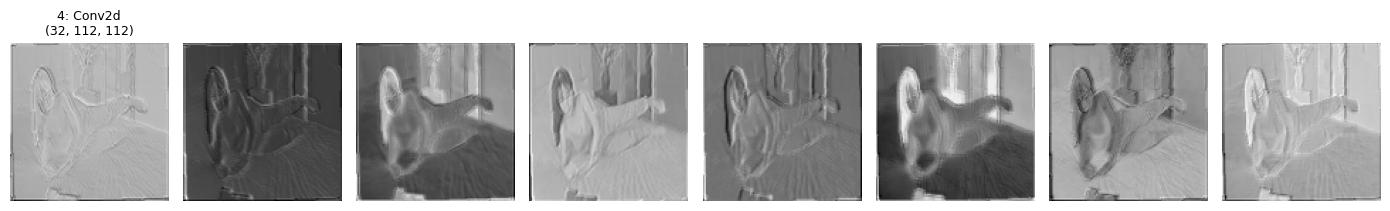

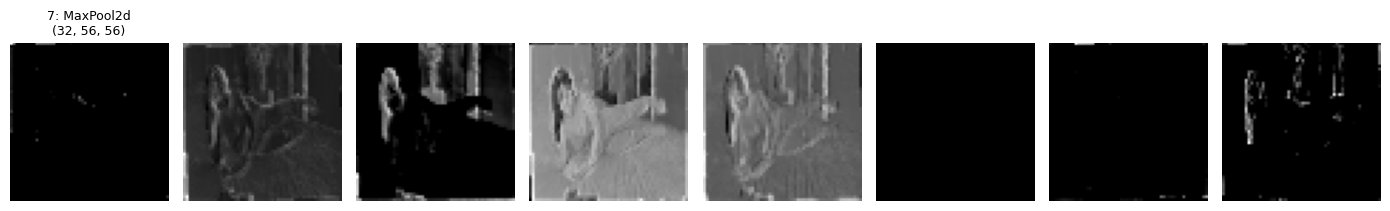

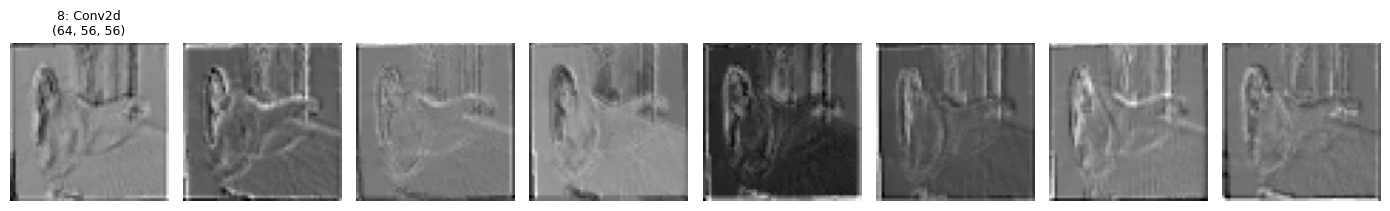

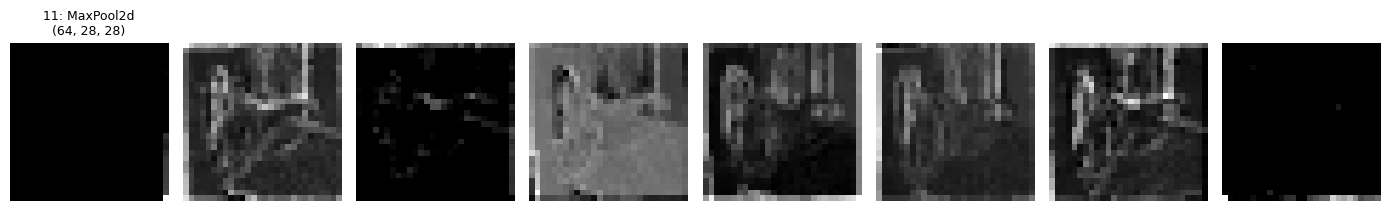

In [56]:
# Pass one image through the CNN and visualize intermediate feature maps
model = SimplePostureCNN(num_classes=len(class_names))
model.eval()

x = images[0:1]  # one image: [1, 3, 256, 256]
activations = [("Input", x)]

with torch.no_grad():
    z = x
    for i, layer in enumerate(model.features):
        z = layer(z)
        if isinstance(layer, (nn.Conv2d, nn.MaxPool2d)):
            activations.append((f"{i}: {layer.__class__.__name__}", z))

# Plot
for title, feat in activations:
    feat = feat.squeeze(0).cpu()  # [C, H, W]
    n_maps = min(8, feat.shape[0])

    plt.figure(figsize=(14, 3))
    for j in range(n_maps):
        ax = plt.subplot(1, n_maps, j + 1)

        plt.imshow(feat[j].numpy(), cmap="gray")
        plt.axis("off")
        if j == 0:
            plt.title(f"{title}\n{tuple(feat.shape)}", fontsize=9)
    plt.tight_layout()
    plt.show()

In [57]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    return epoch_loss, epoch_acc, all_preds, all_labels



In [58]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
model = SimplePostureCNN(num_classes=len(class_names)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)
print("Using device:", device)



SimplePostureCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=256, bias=True)
    (2): ReLU()
    (3): 

In [59]:
num_epochs = 20

history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": [],
}

best_model_wts = copy.deepcopy(model.state_dict())
best_valid_acc = 0.0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    valid_loss, valid_acc, valid_preds, valid_labels = evaluate(model, valid_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["valid_loss"].append(valid_loss)
    history["valid_acc"].append(valid_acc)

    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        best_model_wts = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}"
    )

# Load best model
model.load_state_dict(best_model_wts)
print(f"\nBest validation accuracy: {best_valid_acc:.4f}")



Epoch 01/20 | Train Loss: 6.1337 | Train Acc: 0.5353 | Valid Loss: 3.2541 | Valid Acc: 0.2685
Epoch 02/20 | Train Loss: 0.8094 | Train Acc: 0.6763 | Valid Loss: 1.2260 | Valid Acc: 0.4352
Epoch 03/20 | Train Loss: 0.5919 | Train Acc: 0.7905 | Valid Loss: 1.2772 | Valid Acc: 0.4352
Epoch 04/20 | Train Loss: 0.5084 | Train Acc: 0.8237 | Valid Loss: 1.2047 | Valid Acc: 0.4537
Epoch 05/20 | Train Loss: 0.4615 | Train Acc: 0.8382 | Valid Loss: 1.2596 | Valid Acc: 0.4722
Epoch 06/20 | Train Loss: 0.4092 | Train Acc: 0.8465 | Valid Loss: 1.3791 | Valid Acc: 0.5741
Epoch 07/20 | Train Loss: 0.3872 | Train Acc: 0.8423 | Valid Loss: 1.4071 | Valid Acc: 0.5278
Epoch 08/20 | Train Loss: 0.4116 | Train Acc: 0.8351 | Valid Loss: 1.4298 | Valid Acc: 0.4815
Epoch 09/20 | Train Loss: 0.3456 | Train Acc: 0.8641 | Valid Loss: 1.4318 | Valid Acc: 0.5370
Epoch 10/20 | Train Loss: 0.3175 | Train Acc: 0.8797 | Valid Loss: 1.3747 | Valid Acc: 0.5556
Epoch 11/20 | Train Loss: 0.2978 | Train Acc: 0.8869 | Valid

This clearly was not a great result, our data is probably too complex for the simple model that we choose. 
The best strategy is not to create out own model, rather to use other models that people have created, trained, and tested with large datasets. 

These models are sometimes called as **Foundation Models**, you can take these models and adapt them to your problem. 
Most of the time you won't create your own model, rather, you will take a pre-build model and adapt it with your data, this process is called **Fine-Tuning**.

Let us fine tune a well known model using our data. 



In [60]:
from torchvision import models

#this is a well know model architecture that has been pre-trained on a large dataset (ImageNet), so it has already learned useful features for image classification. We can use it as a starting point
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
#we can adapt th final layer to our specific task (3 classes)
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

#when fine tuning a pre-trained model, you must use the same normalization as the original training data (ImageNet)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

valid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

#it is also common to use a smaller learning rate when fine tuning, since the model already has good weights and we don't want to change them too much
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 20

history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": [],
}

best_model_wts = copy.deepcopy(model.state_dict())
best_valid_acc = 0.0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    valid_loss, valid_acc, valid_preds, valid_labels = evaluate(model, valid_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["valid_loss"].append(valid_loss)
    history["valid_acc"].append(valid_acc)

    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        best_model_wts = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}"
    )

# Load best model
model.load_state_dict(best_model_wts)
print(f"\nBest validation accuracy: {best_valid_acc:.4f}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/diegoguarin/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:02<00:00, 16.1MB/s]


Epoch 01/20 | Train Loss: 0.4383 | Train Acc: 0.8195 | Valid Loss: 0.4877 | Valid Acc: 0.8426
Epoch 02/20 | Train Loss: 0.0813 | Train Acc: 0.9730 | Valid Loss: 0.4423 | Valid Acc: 0.8519
Epoch 03/20 | Train Loss: 0.0424 | Train Acc: 0.9896 | Valid Loss: 0.4619 | Valid Acc: 0.8611
Epoch 04/20 | Train Loss: 0.0359 | Train Acc: 0.9876 | Valid Loss: 0.5084 | Valid Acc: 0.8611
Epoch 05/20 | Train Loss: 0.0196 | Train Acc: 0.9938 | Valid Loss: 0.4401 | Valid Acc: 0.8519
Epoch 06/20 | Train Loss: 0.0207 | Train Acc: 0.9959 | Valid Loss: 0.4379 | Valid Acc: 0.8056
Epoch 07/20 | Train Loss: 0.0093 | Train Acc: 0.9990 | Valid Loss: 0.4328 | Valid Acc: 0.8241
Epoch 08/20 | Train Loss: 0.0084 | Train Acc: 0.9990 | Valid Loss: 0.4291 | Valid Acc: 0.8241
Epoch 09/20 | Train Loss: 0.0269 | Train Acc: 0.9886 | Valid Loss: 0.4395 | Valid Acc: 0.8704
Epoch 10/20 | Train Loss: 0.0112 | Train Acc: 0.9979 | Valid Loss: 0.6094 | Valid Acc: 0.8704
Epoch 11/20 | Train Loss: 0.0148 | Train Acc: 0.9948 | Valid

In [65]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

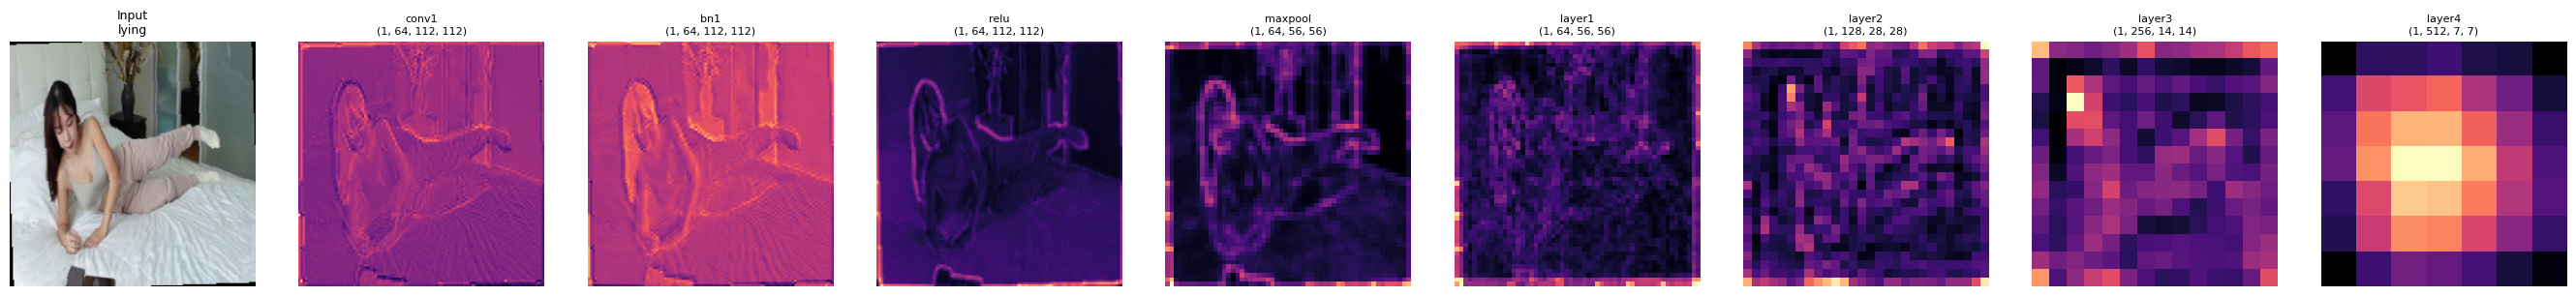

In [63]:
# Visualize intermediate activations from key ResNet stages
model.eval()

x = images[0:1].to(device)  # one sample
stage_outputs = [("input", x.detach().cpu())]

with torch.no_grad():
    z = x
    stages = [
        ("conv1", model.conv1),
        ("bn1", model.bn1),
        ("relu", model.relu),
        ("maxpool", model.maxpool),
        ("layer1", model.layer1),
        ("layer2", model.layer2),
        ("layer3", model.layer3),
        ("layer4", model.layer4),
    ]
    for name, layer in stages:
        z = layer(z)
        stage_outputs.append((name, z.detach().cpu()))

# Plot input + mean activation map per stage
n_cols = len(stage_outputs)
fig, axes = plt.subplots(1, n_cols, figsize=(3 * n_cols, 3))

for i, (name, feat) in enumerate(stage_outputs):
    ax = axes[i]
    if name == "input":
        img = feat[0].permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(f"Input\n{class_names[labels[0]]}", fontsize=9)
    else:
        # Average across channels to get one 2D activation map
        act_map = feat[0].mean(dim=0).numpy()
        ax.imshow(act_map, cmap="magma")
        ax.set_title(f"{name}\n{tuple(feat.shape)}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()